Assignment 5:

Name: Arik Gershman

# Affine Structure from Motion (50 points)

## Overview
<img src="https://drive.google.com/uc?id=1nafVVzFvH87RNrwgLurW9oUO1rwlgSvf" width="800"/>


This problem continues the interest point detection and tracking problem from HW2. Now, you will recover a 3D pointcloud from the image sequence hotel.seq0.png … hotel.seq50.png. You are encouraged to use your results from HW2, but in case you were not able to complete it, we have also included pre- computed intermediate results in the supplemental material. Submit your code so that we can reproduce your results.

The outline of the affine structure from motion algorithm:

<img src="https://drive.google.com/uc?id=1ZrJosAp1sFzsRRcRMpWBRIDNZmq8ZL2q" width="700"/>

<img src="https://drive.google.com/uc?id=15SHk9Q-CD0SZn9tiSGLZ5XJOyx0GPJD3" width="700" />

<img src="https://drive.google.com/uc?id=1b5phH3iK5D4hJY8HttU73ePdb2IylYrL" width="700"/>


In [107]:
## Import necessary libraries here (You can add libraries you want to use here)
import os
import random
import cv2
import numpy as np
from scipy.io import loadmat
import matplotlib.pyplot as plt
from matplotlib import cm
%matplotlib inline

## Data

**WARNING: Colab deletes all files everytime runtime is disconnected. Make sure to re-download the inputs when it happens.**

In [108]:
# Download Data -- run this cell only one time per runtime
!gdown 1A0Rin_YMmWkExjI99vfLYvU_dy-9gFTT
!unzip "/content/Part2_data.zip" -d "/content/"
# Load Matches
data = loadmat('/content/Part2_data/tracks.mat')

Downloading...
From: https://drive.google.com/uc?id=1A0Rin_YMmWkExjI99vfLYvU_dy-9gFTT
To: /content/Part2_data.zip
100% 5.44M/5.44M [00:00<00:00, 22.3MB/s]
Archive:  /content/Part2_data.zip
replace /content/Part2_data/images/hotel.seq0.png? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
  inflating: /content/Part2_data/images/hotel.seq0.png  
  inflating: /content/Part2_data/images/hotel.seq1.png  
  inflating: /content/Part2_data/images/hotel.seq10.png  
  inflating: /content/Part2_data/images/hotel.seq11.png  
  inflating: /content/Part2_data/images/hotel.seq12.png  
  inflating: /content/Part2_data/images/hotel.seq13.png  
  inflating: /content/Part2_data/images/hotel.seq14.png  
  inflating: /content/Part2_data/images/hotel.seq15.png  
  inflating: /content/Part2_data/images/hotel.seq16.png  
  inflating: /content/Part2_data/images/hotel.seq17.png  
  inflating: /content/Part2_data/images/hotel.seq18.png  
  inflating: /content/Part2_data/images/hotel.seq19.png  
  inflating: /content/Part

## Code [30 pts]


In [109]:
from operator import length_hint
def perform_rank3_svd(D):
    """
    Perform SVD on the measurement matrix D and enforce a rank 3 approximation.

    Note: Later steps in the algorithm use W3 to build up the motion and structure matrices.

    Parameters
    ----------
    D : numpy.ndarray
        The measurement matrix of shape (m, n).

    Returns
    -------
    U3 : numpy.ndarray
        The left singular vectors (first 3 columns) of shape (num_frames*2, 3).
    W3 : numpy.ndarray
        The diagonal matrix containing the square roots of the top three singular values, of shape (3, 3).
    V3 : numpy.ndarray
        The first 3 columns of V, shape (num_points, 3).
    """
    U,W,V = np.linalg.svd(D)
    U3 = U[:,:3]
    W3 = np.diag(W[:3])
    V3 = V.T[:,:3]
    return U3, W3, V3

def build_ortho_constraint_system(A):
    """
    Build the orthographic constraint system from the motion matrix A.

    Parameters
    ----------
    A : numpy.ndarray, shape (2 * num_frames, 3)
        The uncorrected motion matrix from the SVD step, where the top half (ai) corresponds
        to x measurements and the bottom half (aj) corresponds to y measurements.

    Returns
    -------
    constraint_matrix : numpy.ndarray, shape (3 * num_frames, 9)
        The left-hand side (lhs) constraint matrix, built using outer products.
    ks (`k` in the slides) : numpy.ndarray, shape (3 * num_frames, 1)
        The right-hand side (rhs) vector for the system. The constraints on the squared norms
        are set to 1 (for the first two equations of each frame) while the cross-product
        constraint is set to 0.
    """
    # Separate the motion matrix A into the parts corresponding to x and y:
    num_frames = A.shape[0]//2
    ai = A[0:num_frames]
    aj = A[num_frames:]

    # There are 3 constraints per frame:
    # ||ai||^2 = 1, ||aj||^2 = 1, and ai^T * aj = 0.


    constraint_matrix = np.zeros((3*num_frames, 9))
    ks = np.zeros((3*num_frames, 1))
    # For each frame, fill in the three constraints to finish left-hand side (lhs) and right-hand side (rhs)
    ## Psudo codes
    for i, (ai_row, aj_row) in enumerate(zip(ai, aj)):
      idx = 3 * i
      constraint_matrix[idx    ] = np.outer(ai_row, ai_row).flatten() # -> outer product of ai_row with itself (ai_row x ai_row)
      constraint_matrix[idx + 1] = np.outer(aj_row, aj_row).flatten() # -> outer product of aj_row with itself (aj_row x aj_row)
      constraint_matrix[idx + 2] = np.outer(ai_row, aj_row).flatten() # -> outer product of ai_row and aj_row  (ai_row x aj_row)
      ks[idx : idx + 3] = np.transpose(np.array([[1,1,0]])) # -> [1, 1, 0]^T


    return constraint_matrix, ks

def affineSFM(x, y):
  '''
  Affine Structure from Motion (SFM) Algorithm.

  This function implements an Affine Structure from Motion approach to recover
  the 3D structure of a scene and estimate the camera motion from its 2D projections.
  It assumes an orthographic camera model and employs Singular Value Decomposition (SVD)
  to enforce a rank-3 constraint, followed by a correction step that applies orthographic
  projection constraints.

  The algorithm proceeds as follows:
    1. Normalize the measurements: Subtract the mean from each column of x and y so that
        the data is zero mean across each frame.
    2. Construct the measurement matrix D: Stack the transposed normalized x and y coordinates.
        This results in a D of shape (num_frames*2, num_points), where each pair of rows corresponds
        to the x and y measurements for a given frame.
    3. Perform SVD and enforce a rank-3 model: Decompose the measurement matrix and retain only the
        top three singular values and corresponding vectors to satisfy the rank-3 condition.
    4. Apply orthographic constraints: Establish and solve a system of equations based on the
        orthographic projection properties of the affine camera, then use a Cholesky decomposition
        to refine the solution.
    5. Recover the motion and structure matrices:
        - A_corrected: The refined camera motion (affine projection) matrix of shape (num_frames*2, 3)
        - S_corrected: The 3D structure (shape) matrix of the scene of shape (3, num_points)

  Parameters
  ----------
  x : numpy.ndarray, shape (num_points, num_frames)
      A 2D array of x-coordinate feature measurements across frames.
  y : numpy.ndarray, shape (num_points, num_frames)
      A 2D array of y-coordinate feature measurements across frames.

  Returns
  -------
  A_corrected : numpy.ndarray, shape (num_frames*2, 3)
      The refined affine camera motion matrix that maps the 3D structure to the observed 2D coordinates.
  S_corrected : numpy.ndarray, shape (3, num_points)
      The reconstructed 3D structure matrix, representing the positions of feature points in 3D space.
  '''
  ##### YOUR CODE HERE #####
  # Step 1:
  # Normalize x and y to zero mean.
  # Compute the mean for each column (i.e., each frame).
  # After normalization, the shape should still be (num_points, num_frames)
  x_norm = x - np.mean(x, axis=0)
  y_norm = y - np.mean(y, axis=0)

  # Step 2:
  # Create measurement matrix D.
  # The shape of D should be (num_frames*2, num_points)
  D = np.vstack([x_norm.T, y_norm.T])

  # Step 3:
  # Perform SVD and enforce rank 3
  # See https://numpy.org/doc/2.2/reference/generated/numpy.linalg.svd.html for details.
  U3, W3, V3 = perform_rank3_svd(D)

  # Step 4:
  # Create motion and shape matrices A, S
  # A = UW^(1/2)
  # S = W^(1/2)V^T
  A = U3 @ np.sqrt(W3)
  S = np.sqrt(W3) @ V3.T

  # Step 5:
  # Set up the orthographic constraint system to solve for L.
  # Each frame contributes 3 constraints:
  #   ||ai||^2 = 1, ||aj||^2 = 1, ai^T aj = 0
  #
  # For more details:
  #   Each constraint can be written as:
  #       (outer product of two rows) · vec(L) = k
  #   e.g., using ai = [a b c], aj = [d e f]:
  #       outer(ai, aj) → [ad ae af bd be bf cd ce cf]
  #
  # Or:
  #   lhs @ vec(L) = rhs
  #
  # Finish `build_ortho_constraint_system`
  # Make sure passing the sanity check below
  # Hint: use np.outer for outer product.
  constraint_matrix, rhs = build_ortho_constraint_system(A)

  # Step 6:
  # Solve the least squares for L
  # See https://numpy.org/doc/2.1/reference/generated/numpy.linalg.lstsq.html
  # for more details
  L_vec = np.linalg.lstsq(constraint_matrix, rhs)[0]
  L = L_vec.reshape((3, 3))

  # Step 7:
  # Cholesky decomposition. See https://numpy.org/doc/2.2/reference/generated/numpy.linalg.cholesky.html
  C = np.linalg.cholesky(L)

  # Step 8:
  # Update A and S with the constraints
  # to get A_corrected and S_corrected
  A_corrected = A @ C
  S_corrected = np.linalg.inv(C) @ S

  return A_corrected, S_corrected

### Sanity check - perform_rank3_svd()

In [110]:
# Sanity check for rank-3 SVD
np.random.seed(0)  # For reproducibility

D = np.random.randn(8, 10)

# Perform the rank-3 SVD
U3, W3, V3 = perform_rank3_svd(D)

# Print the shapes to check they are as expected.
print("U3 shape:", U3.shape)  # Expected: (8, 3) if D is (8, 10)
print("W3 shape:", W3.shape)  # Expected: (3, 3)
print("V3 shape:", V3.shape)  # Expected: (10, 3)

print(U3)
print(W3)
print(V3)

U3 shape: (8, 3)
W3 shape: (3, 3)
V3 shape: (10, 3)
[[ 0.53246692  0.45719775 -0.15921115]
 [ 0.3115632   0.00164329  0.32281968]
 [ 0.43344853 -0.62446345 -0.58126173]
 [-0.16679875 -0.26983316  0.43462257]
 [-0.4874529   0.34449376 -0.55173433]
 [-0.17789561 -0.25325639  0.11268204]
 [-0.3544282  -0.34054681 -0.15616012]
 [ 0.09397544 -0.17151124  0.04672569]]
[[5.1812973  0.         0.        ]
 [0.         4.76627564 0.        ]
 [0.         0.         4.09283553]]
[[ 0.16000216  0.48858191  0.47244524]
 [ 0.31832224 -0.17030302  0.26373828]
 [ 0.50159274 -0.04793424  0.06489539]
 [ 0.19198533  0.79587716 -0.42622534]
 [ 0.46376952 -0.16087835 -0.33118127]
 [-0.16549708  0.08699357  0.36584415]
 [ 0.3630006   0.06973369  0.42800566]
 [-0.20794436 -0.03024835  0.02322414]
 [ 0.37894031 -0.19559239  0.0010515 ]
 [ 0.15342463 -0.1381398  -0.30676682]]


Expected output:
```
D shape: (8, 10)
U3 shape: (8, 3)
W3 shape: (3, 3)
V3 shape: (10, 3)
[[ 0.53246692  0.45719775 -0.15921115]
 [ 0.3115632   0.00164329  0.32281968]
 [ 0.43344853 -0.62446345 -0.58126173]
 [-0.16679875 -0.26983316  0.43462257]
 [-0.4874529   0.34449376 -0.55173433]
 [-0.17789561 -0.25325639  0.11268204]
 [-0.3544282  -0.34054681 -0.15616012]
 [ 0.09397544 -0.17151124  0.04672569]]
[[5.1812973  0.         0.        ]
 [0.         4.76627564 0.        ]
 [0.         0.         4.09283553]]
[[ 0.16000216  0.48858191  0.47244524]
 [ 0.31832224 -0.17030302  0.26373828]
 [ 0.50159274 -0.04793424  0.06489539]
 [ 0.19198533  0.79587716 -0.42622534]
 [ 0.46376952 -0.16087835 -0.33118127]
 [-0.16549708  0.08699357  0.36584415]
 [ 0.3630006   0.06973369  0.42800566]
 [-0.20794436 -0.03024835  0.02322414]
 [ 0.37894031 -0.19559239  0.0010515 ]
 [ 0.15342463 -0.1381398  -0.30676682]]
```

### Sanity check - build_ortho_constraint_system()

In [111]:
# Sanity check for build_ortho_constraint_system()
A_simple = np.array([
    [1, 2, 3],   # ai for frame 1
    [4, 5, 6],   # ai for frame 2
    [7, 8, 9],   # aj for frame 1
    [10, 11, 12] # aj for frame 2
])
constraints_lhs, constraints_rhs = build_ortho_constraint_system(A_simple)

expected_lhs = np.array(
 [[  1.,   2.,   3.,   2.,   4.,   6.,   3.,   6.,   9.],
 [ 49.,  56.,  63.,  56.,  64.,  72.,  63.,  72.,  81.],
 [  7.,   8.,   9.,  14.,  16.,  18.,  21.,  24.,  27.],
 [ 16.,  20.,  24.,  20.,  25.,  30.,  24.,  30.,  36.],
 [100., 110., 120., 110., 121., 132., 120., 132., 144.],
 [ 40.,  44.,  48.,  50.,  55.,  60.,  60.,  66.,  72.]]
)
expected_rhs = np.array(
 [[ 1.],
 [ 1.],
 [ 0.],
 [ 1.],
 [ 1.],
 [ 0.]]
)
print("Constraints LHS:")
print(constraints_lhs)
print("Constraints RHS:")
print(constraints_rhs)

assert np.allclose(constraints_lhs, expected_lhs), "Constraints LHS not correct"
assert np.allclose(constraints_rhs, expected_rhs), "Constraints RHS not correct"

print("Passed!")

Constraints LHS:
[[  1.   2.   3.   2.   4.   6.   3.   6.   9.]
 [ 49.  56.  63.  56.  64.  72.  63.  72.  81.]
 [  7.   8.   9.  14.  16.  18.  21.  24.  27.]
 [ 16.  20.  24.  20.  25.  30.  24.  30.  36.]
 [100. 110. 120. 110. 121. 132. 120. 132. 144.]
 [ 40.  44.  48.  50.  55.  60.  60.  66.  72.]]
Constraints RHS:
[[1.]
 [1.]
 [0.]
 [1.]
 [1.]
 [0.]]
Passed!


### Data preprocessing

In [112]:
track_x = data['track_x']
track_y = data['track_y']
print(track_x.shape)
print(track_y.shape)

# Remove the nan value
valid_indices = ~np.isnan(track_x).any(axis=1) & ~np.isnan(track_y).any(axis=1)
valid_x = track_x[valid_indices]
valid_y = track_y[valid_indices]
print(valid_x.shape)
print(valid_y.shape)

(500, 51)
(500, 51)
(400, 51)
(400, 51)


## Write-up [20 pts]


*   Plot the predicted 3D locations of the tracked points for 3 different viewpoints. Choose the viewpoints so that the 3D structure is clearly visible.


(400, 51)


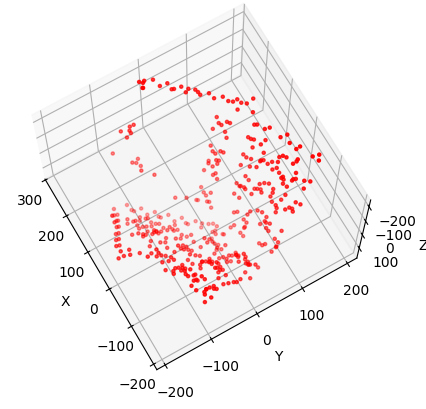

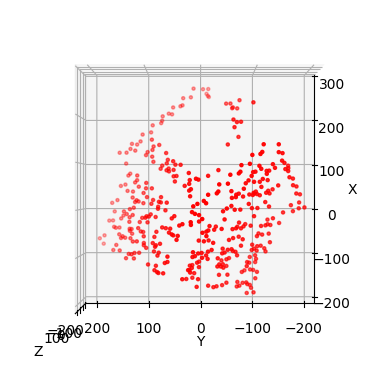

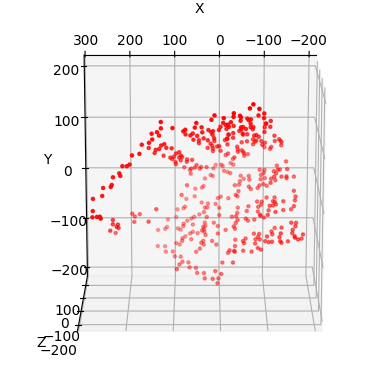

In [113]:
print(valid_x.shape)
A, S = affineSFM(valid_x, valid_y)

# Plot the predicted 3D locations of the tracked points for 3 different viewpoints.
# Choose the viewpoints so that the 3D structure is clearly visible.
viewpoints = [(-110, 30), (90, 180), (-75, 90)]

for elev, azim in viewpoints:
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(S[0, :], S[1, :], S[2, :], c='r', marker='.')
    ax.view_init(elev=elev, azim=azim)
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    plt.show()

*   Plot the predicted 3D path of the cameras. The camera position for each frame is given by the cross product a_k = a_i x a_j. Normalize a_k to be unit length for consistent results. Give 3 plots, one for each dimension of a_k

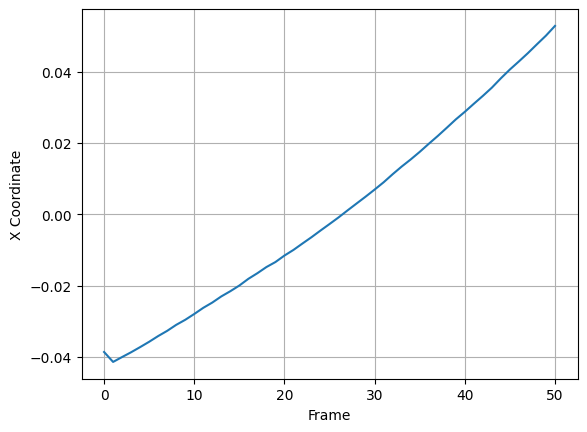

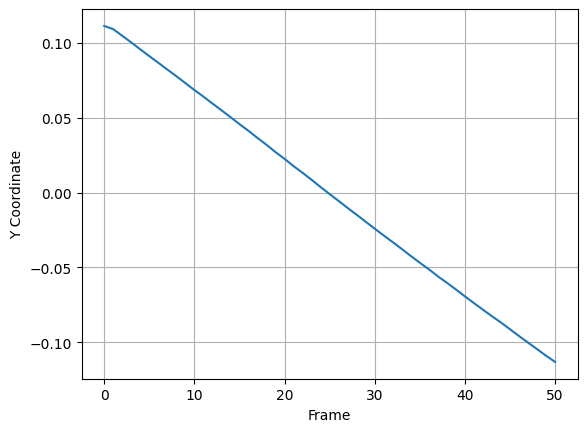

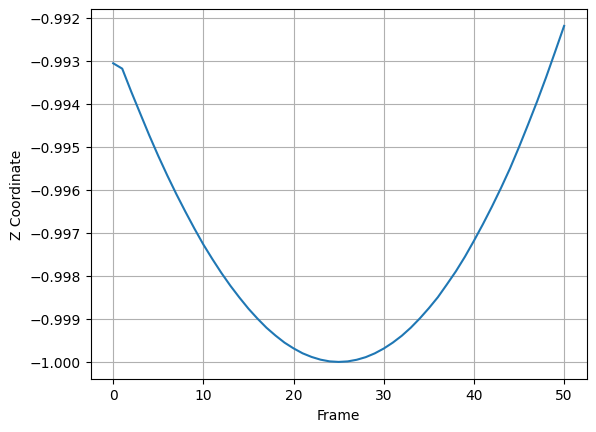

In [114]:
# Plot the predicted 3D path of the cameras. The camera position for each frame is given by the cross product a_k = a_i x a_j.
# Normalize a_k to be unit length for consistent results. Give 3 plots, one for each dimension of a_k
ai = A[:A.shape[0]//2, :]
aj = A[A.shape[0]//2:, :]
ak = np.cross(ai, aj)
ak /= np.linalg.norm(ak, axis=1)[:, np.newaxis]

for i, label in enumerate(['X', 'Y', 'Z']):
    plt.plot(ak[:, i])
    plt.xlabel('Frame')
    plt.ylabel(f'{label} Coordinate')
    plt.grid(True)
    plt.show()

### Hint


*   Do not use existing structure from motion code, such as found in OpenCV.
*   The provided file tracks.mat contains the tracked keypoints over 51 frames.viewpoints.
*   Reference:
    - Tomasi and Kanade. Shape and Motion from Image Streams under Orthography: a Factorization Method. 1992

# Save as a PDF file
Make sure you have run Dependecies below. It will take a while.
If the following code does not work for you, go `File > Print > Save`.

In [121]:
!apt-get update
!dpkg --configure -a
!apt-get install -y texlive texlive-xetex texlive-latex-extra pandoc
!pip install pypandoc

Get:1 https://cli.github.com/packages stable InRelease [3,917 B]
Get:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Hit:3 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:4 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:5 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:6 https://cli.github.com/packages stable/main amd64 Packages [354 B]
Get:7 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:8 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:9 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [89.0 kB]
Get:10 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Hit:11 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:12 https://r2u.stat.illinois.edu/ubuntu jammy/main amd64 Packages [2,970 kB]
Get:13 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 Packages [4,264 kB]
Get:14 https://r2u

You will be prompted for permissions to Google Drive.

In [116]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Change the path accordingly below. You will find PDF file on your left hand side.

In [122]:
# Feel free to change the path
# !cp <path-to-this-notebook-in-GoogleDrive> ./
##### Reminder #####
# Make sure that you can find your ipynb file under /content/drive/MyDrive or /content/drive/MyDrive/Colab_Notebooks or your path/to/ipynb_file
####################
!cp /content/drive/MyDrive/CMSC426/CMSC426_Assignment4_sp26.ipynb ./ # subject to change
!jupyter nbconvert --to PDF "CMSC426_Assignment4_sp26.ipynb"
# PDF file will be on the left hand side bar

[NbConvertApp] Converting notebook CMSC426_Assignment4_sp26.ipynb to PDF
[NbConvertApp] Support files will be in CMSC426_Assignment4_sp26_files/
[NbConvertApp] Making directory ./CMSC426_Assignment4_sp26_files
[NbConvertApp] Writing 69107 bytes to notebook.tex
[NbConvertApp] Building PDF
[NbConvertApp] Running xelatex 3 times: ['xelatex', 'notebook.tex', '-quiet']
[NbConvertApp] Running bibtex 1 time: ['bibtex', 'notebook']
[NbConvertApp] WARNING | bibtex had problems, most likely because there were no citations
[NbConvertApp] PDF successfully created
[NbConvertApp] Writing 300549 bytes to CMSC426_Assignment4_sp26.pdf
